# Assessment 2

Name: Chayut Deekongsieng \
Student ID: 46800883

In [2]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore') #ignore the warning
import matplotlib.pyplot as plt

In [3]:
koala = pd.read_excel("koalas_dataset.xlsx")
koala.head()

,koala_id,region,habitat,gender,age_in_years,Paw Size,total_length,head_length,ear_size,foot_length,skull_width,eye_diameter,chest_circumference,belly_circumference
0,1,1,VIC,m,8.0,16.0,77.0,19.1,19.5,24.5,15.4,2.2,63.0,61.0
1,2,1,VIC,f,6.0,16.5,79.5,17.5,16.2,22.5,12.6,3.0,63.5,58.0
2,3,1,VIC,f,6.0,19.0,83.5,19.0,16.9,25.4,15.0,2.5,65.0,59.0
3,4,1,VIC,f,6.0,18.0,80.0,18.2,17.2,26.1,12.1,2.2,63.0,59.0
4,5,1,VIC,f,2.0,16.0,73.5,16.5,18.2,21.0,11.3,2.1,63.5,58.0


## Section 1: Exploratory Data Analysis

In [5]:
koala.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   koala_id             104 non-null    int64  
 1   region               104 non-null    int64  
 2   habitat              104 non-null    object 
 3   gender               104 non-null    object 
 4   age_in_years         102 non-null    float64
 5   Paw Size             104 non-null    float64
 6   total_length         104 non-null    float64
 7   head_length          104 non-null    float64
 8   ear_size             104 non-null    float64
 9   foot_length          102 non-null    float64
 10  skull_width          103 non-null    float64
 11  eye_diameter         104 non-null    float64
 12  chest_circumference  104 non-null    float64
 13  belly_circumference  103 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 11.5+ KB


In [6]:
print("Shape of Koala Dataset", koala.shape)

Shape of Koala Dataset (104, 14)


### Define and remove null or missing values

In [8]:
# checking missing values
koala.isnull().sum()

koala_id               0
region                 0
habitat                0
gender                 0
age_in_years           2
Paw Size               0
total_length           0
head_length            0
ear_size               0
foot_length            2
skull_width            1
eye_diameter           0
chest_circumference    0
belly_circumference    1
dtype: int64

In [9]:
# missing value rows
missing_values = koala[koala.isnull().any(axis=1)]
missing_values

,koala_id,region,habitat,gender,age_in_years,Paw Size,total_length,head_length,ear_size,foot_length,skull_width,eye_diameter,chest_circumference,belly_circumference
40,41,2,VIC,f,5.0,16.5,71.0,13.4,5.3,NaN,12.0,2.9,62.0,55.5
43,44,2,VIC,m,NaN,15.5,64.0,10.1,17.6,20.3,6.5,1.4,58.0,52.0
45,46,2,VIC,m,NaN,15.0,72.0,16.4,16.2,22.8,9.4,1.4,59.5,60.0
64,65,5,QLD,f,5.0,18.0,76.5,18.5,6.7,NaN,12.4,1.0,64.0,63.5
75,76,6,QLD,m,5.0,21.0,77.0,17.4,11.4,14.5,11.8,4.8,61.0,NaN
88,89,7,QLD,m,6.0,15.0,72.5,22.7,11.2,14.4,NaN,1.4,64.0,55.5


Since the missing values are all numerical values, hence it should be suitable to replace it with their column mean values

In [11]:
print('Mean of age_in_years: ',koala['age_in_years'].mean())
print('Mean of foot_length: ',koala['foot_length'].mean())
print('Mean of skull_width: ',koala['skull_width'].mean())
print('Mean of belly_circumference: ',koala['belly_circumference'].mean())

Mean of age_in_years:  3.8333333333333335
Mean of foot_length:  18.461764705882352
Mean of skull_width:  12.91747572815534
Mean of belly_circumference:  57.58252427184466


In [12]:
koala['age_in_years'] = koala['age_in_years'].fillna(koala['age_in_years'].mean())
koala['foot_length'] = koala['foot_length'].fillna(koala['foot_length'].mean())
koala['skull_width'] = koala['skull_width'].fillna(koala['skull_width'].mean())
koala['belly_circumference'] = koala['belly_circumference'].fillna(koala['belly_circumference'].mean())

In [13]:
# Ensuring all of null values are removed
koala.isnull().sum()

koala_id               0
region                 0
habitat                0
gender                 0
age_in_years           0
Paw Size               0
total_length           0
head_length            0
ear_size               0
foot_length            0
skull_width            0
eye_diameter           0
chest_circumference    0
belly_circumference    0
dtype: int64

### Handling misspelling/ invalid type entries

In [15]:
categorical_col = koala.select_dtypes(exclude=['number']).columns
categorical_col

Index(['habitat', 'gender'], dtype='object')

There are 2 categorical-value columns that might to further investigate unique values inside.

In [17]:
print(koala['habitat'].unique())
print(koala['gender'].unique())

['VIC' 'VICtoria' 'Vic' 'QLD' 'Queensland' 'Queenstown' 'qld' 'q']
['m' 'f' 'female' 'male']


In [18]:
# Define correction columns for those two categorical columns
correction_habitat = {'VICtoria':'VIC','Vic':'VIC','Queensland':'QLD','Queenstown':'QLD','qld':'QLD','q':'QLD'}
correction_gender = {'m':'male','f':'female'}

# Replace misspelled with corrections for categorical columns
koala['habitat'] = koala['habitat'].replace(correction_habitat)
koala['gender'] = koala['gender'].replace(correction_gender)

In [19]:
# Confirming categorical values in the columns
print(koala['habitat'].unique())
print(koala['gender'].unique())

['VIC' 'QLD']
['male' 'female']


### Checking Data Distribution and Removing Outliers

In [21]:
koala.describe()

,koala_id,region,age_in_years,Paw Size,total_length,head_length,ear_size,foot_length,skull_width,eye_diameter,chest_circumference,belly_circumference
count,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000
mean,52.500000,3.625000,3.833333,17.009615,75.088462,18.554808,22.650000,18.461765,12.917476,5.886538,62.000000,57.582524
std,30.166206,2.349086,1.890617,1.959518,4.310549,9.761017,87.562416,4.373842,11.106181,39.082636,2.045597,2.761645
min,1.000000,1.000000,1.000000,12.000000,63.000000,7.500000,5.300000,10.300000,5.000000,0.500000,57.000000,50.000000
25%,26.750000,1.000000,2.750000,15.875000,72.000000,15.700000,9.875000,14.650000,9.975000,1.400000,60.500000,56.000000
50%,52.500000,3.000000,3.000000,17.000000,76.000000,17.850000,11.900000,18.200000,11.350000,1.900000,62.000000,57.500000
75%,78.250000,6.000000,5.000000,18.000000,78.000000,19.800000,17.025000,22.500000,13.100000,2.725000,63.000000,59.125000
max,104.000000,7.000000,9.000000,23.000000,84.500000,110.500000,900.800000,27.900000,120.600000,400.500000,67.000000,65.000000


### Define Outliers by plotting outliers

In [23]:
import matplotlib.pyplot as plt

# List of columns
numerical_cols= ['age_in_years', 'Paw Size', 'total_length', 'head_length', 'ear_size',
                   'foot_length', 'skull_width', 'eye_diameter', 'chest_circumference', 'belly_circumference']

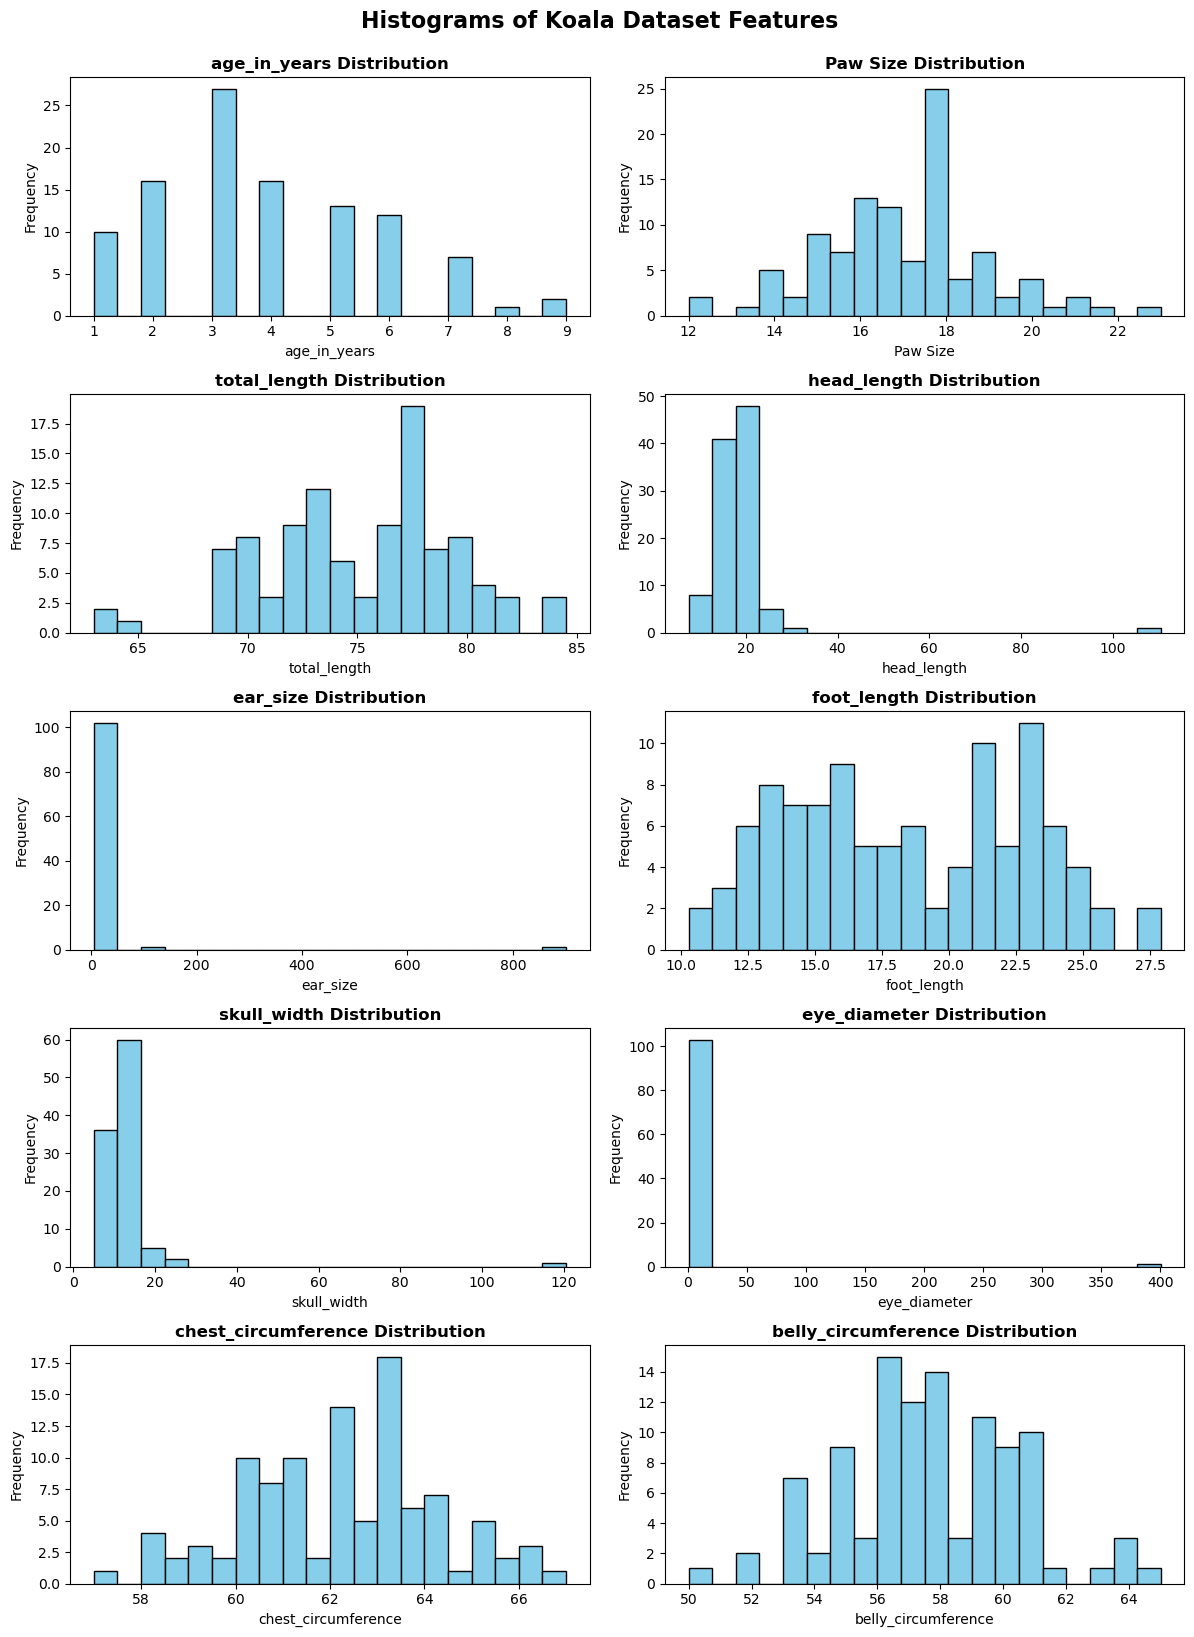

In [24]:
# Create subplots: adjust the number of rows and columns to fit all histograms
fig, axs = plt.subplots(5, 2, figsize=(12, 16))  # 5 rows, 2 columns for 10 plots

# Flatten axs to easily loop through
axs = axs.ravel()

# Plot histograms for each column
for i, col in enumerate(numerical_cols):
    axs[i].hist(koala[col], bins=20, edgecolor='black', color='skyblue')  # Alternate colors
    axs[i].set_title(f'{col} Distribution', fontsize=12, weight='bold')
    axs[i].set_xlabel(col, fontsize=10)
    axs[i].set_ylabel('Frequency', fontsize=10)

# Adjust layout for better spacing and appearance
plt.tight_layout()

# Add a main title for the figure
fig.suptitle('Histograms of Koala Dataset Features', fontsize=16, weight='bold', y=1.02)


# Show the plot
plt.show()


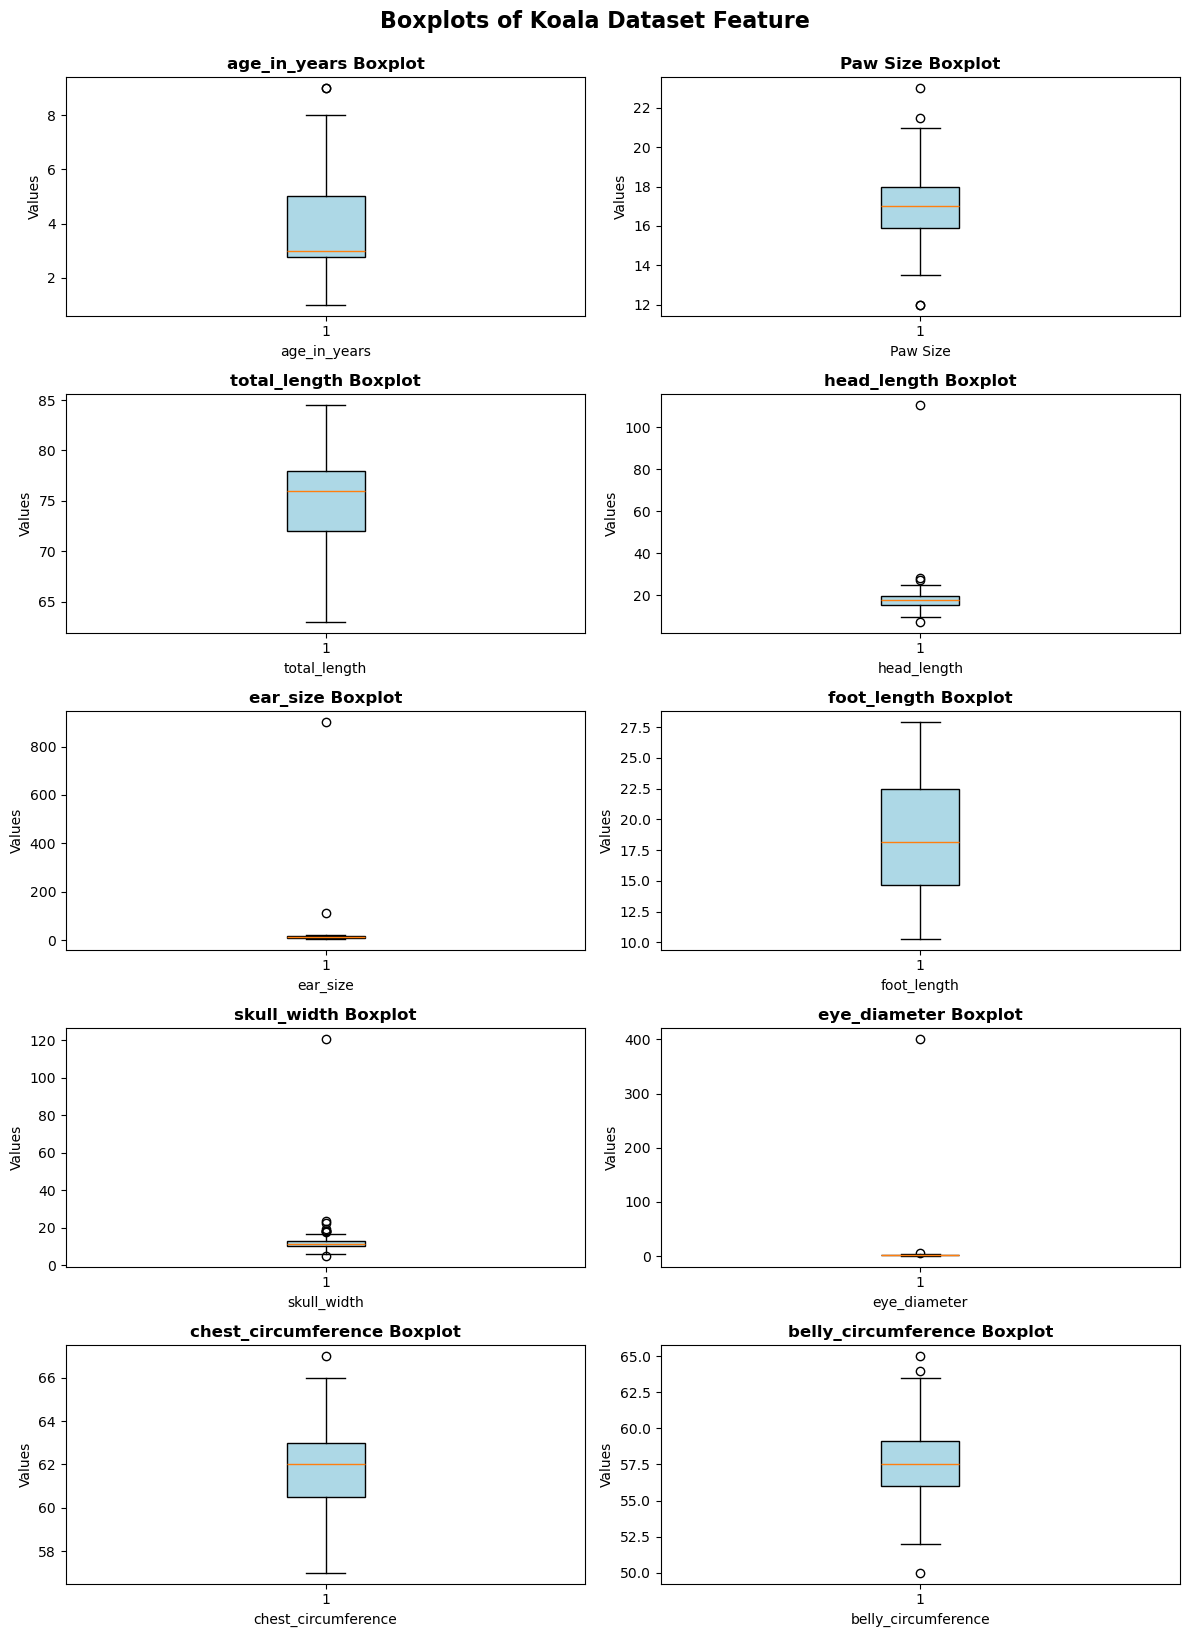

In [25]:
# Create subplots: adjust the number of rows and columns to fit all histograms
fig, axs = plt.subplots(5, 2, figsize=(12, 16))  # 5 rows, 2 columns for 10 plots

# Flatten axs to easily loop through
axs = axs.ravel()

# Plot boxplots for each column
for i, col in enumerate(numerical_cols):
    axs[i].boxplot(koala[col], patch_artist=True,
                   boxprops=dict(facecolor='lightblue'))
    
    # Set titles and labels with better styling
    axs[i].set_title(f'{col} Boxplot', fontsize=12, weight='bold')
    axs[i].set_xlabel(col, fontsize=10)
    axs[i].set_ylabel('Values', fontsize=10)


# Adjust layout for better spacing and appearance
plt.tight_layout()

# Add a main title for the entire figure
fig.suptitle('Boxplots of Koala Dataset Feature', fontsize=16, weight='bold', y=1.02)

# Show the plot
plt.show()

In [26]:
# Define 'detect_outliers' to reduce code repeatiation
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identifying outliers
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    if not outliers.empty:
        print()
        print(f"Outliers in {column}:")
        print(outliers[[column]])  # Display only the column with outliers
        return outliers
    else:
        return None

In [27]:
for col in numerical_cols:
    outliers = detect_outliers(koala, col)


Outliers in age_in_years:
    age_in_years
8            9.0
10           9.0

Outliers in Paw Size:
    Paw Size
41      12.0
42      12.0
53      23.0
86      21.5

Outliers in head_length:
    head_length
54         28.1
58         27.5
72          7.5
77        110.5

Outliers in ear_size:
    ear_size
57     110.4
89     900.8

Outliers in skull_width:
    skull_width
14        120.6
16         22.7
47         18.2
53         18.0
54         18.2
57         19.2
58         17.8
78          5.0
97         23.6

Outliers in eye_diameter:
    eye_diameter
53         400.5
75           4.8

Outliers in chest_circumference:
    chest_circumference
58                 67.0

Outliers in belly_circumference:
    belly_circumference
20                 65.0
38                 50.0
56                 64.0


In [28]:
# Checking skewness of data in each outliers column
from scipy import stats

# Define function to print skewness of each column
def print_skewness(columns):
    for col in columns:
        skew_value = koala[col].skew()
        print(f'Skewness of {col}: {skew_value}')
        
# Call the function to print skewness of numerical columns
print_skewness(numerical_cols)

Skewness of age_in_years: 0.5442630373490612
Skewness of Paw Size: 0.16786870303351742
Skewness of total_length: -0.285265771534212
Skewness of head_length: 8.233721013431943
Skewness of ear_size: 9.992993956629151
Skewness of foot_length: 0.0907054084380688
Skewness of skull_width: 9.021706278249088
Skewness of eye_diameter: 10.188535641454523
Skewness of chest_circumference: -0.05551075216583214
Skewness of belly_circumference: 0.07841220995652716


Regarding the obtained skewness of columns with outlier, there are highky skewness distribution (skewness<-1 or skewness>1) that necessary to be manipulated  including 'head_length', 'ear_size', 'skull_width' and 'eye_diameter'. Whereas for moderately skewness distribution column (-1<skewness<-0.5 or 0.5<skewness<1), 'age_in_years' . On the other hands, remaining columns' skewness are in acceptable range (-0.5<skewness<0.5).

After reviewing the outliers regarding with the skewness of each outlier column, 
- <u>**Removing rows with extreme values that likely to be unrealistic</u>** as compared to the rest in column including; ear_size = 900.8 and 110.4, eye_diameter = 400.5, head_length = 110.5 and skull_width =  120.6.
- <u>**Keep the extreme values that seems plausible**</u>  like age_in_years = 9, as well as other columns like skull_width and belly_circumference, where the remaining outliers appear reasonable, not to extremely different compared to the rest in column.

In [31]:
# Remove rows contained unrealistic extreme values
koala = koala[~koala['ear_size'].isin([900.8, 110.4])]
koala = koala[koala['eye_diameter'] != 400.5] 
koala = koala[koala['head_length'] != 110.5] 
koala = koala[koala['skull_width'] != 120.6] 

In [32]:
koala.shape

(99, 14)

After removing rows with extreme value, recheck the skewness whether we need the further transformaition

In [34]:
print_skewness(numerical_cols)

Skewness of age_in_years: 0.5623976380148998
Skewness of Paw Size: -0.014512497232162318
Skewness of total_length: -0.29499010534783393
Skewness of head_length: -0.02320831402864604
Skewness of ear_size: 0.11130619639514261
Skewness of foot_length: 0.09481765086417197
Skewness of skull_width: 1.1244417448374424
Skewness of eye_diameter: 0.6337343026990503
Skewness of chest_circumference: -0.036450462205740136
Skewness of belly_circumference: 0.11758065235904504


As the new obtaining skewness of columns with outliers, most of columns are in acceptatable range of skewness, some of them have moderately skewness, but it gonna leave them like that because the values still seems plausible. However, there is still one column with highly skewness distribution, 'skull_width', which still require further transformation, in which I choose to cap the outliers at 95 percentile, hopefully, it will reduce the skewness of the column in analysis acceptable range.

In [36]:
# Calculate the 95th percentile for 'skull_width'
cap_value = koala['skull_width'].quantile(0.95)

# Cap only the values that exceed the 95th percentile
koala['skull_width_capped'] = koala['skull_width'].apply(lambda x: min(x, cap_value))

# Compare original and capped values to see the difference
print(koala[['skull_width', 'skull_width_capped']].describe())

       skull_width  skull_width_capped
count    99.000000           99.000000
mean     11.818358           11.643106
std       2.971781            2.482092
min       5.000000            5.000000
25%      10.000000           10.000000
50%      11.300000           11.300000
75%      13.050000           13.050000
max      23.600000           16.630000


In [37]:
# Replace original column with capped version
koala['skull_width'] = koala['skull_width_capped']

# Optionally, you can drop the temporary capped column if no longer needed
koala.drop(columns=['skull_width_capped'], inplace=True)

In [38]:
print_skewness(numerical_cols)

Skewness of age_in_years: 0.5623976380148998
Skewness of Paw Size: -0.014512497232162318
Skewness of total_length: -0.29499010534783393
Skewness of head_length: -0.02320831402864604
Skewness of ear_size: 0.11130619639514261
Skewness of foot_length: 0.09481765086417197
Skewness of skull_width: 0.03469736501697853
Skewness of eye_diameter: 0.6337343026990503
Skewness of chest_circumference: -0.036450462205740136
Skewness of belly_circumference: 0.11758065235904504


In [39]:
koala.describe()

,koala_id,region,age_in_years,Paw Size,total_length,head_length,ear_size,foot_length,skull_width,eye_diameter,chest_circumference,belly_circumference
count,99.000000,99.000000,99.000000,99.000000,99.000000,99.00000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000
mean,52.171717,3.585859,3.835017,16.949495,75.103030,17.59899,13.205051,18.482056,11.643106,2.074747,61.979798,57.561440
std,30.342279,2.356104,1.882684,1.872866,4.327285,3.57969,4.155212,4.432419,2.482092,0.973878,1.996067,2.753723
min,1.000000,1.000000,1.000000,12.000000,63.000000,7.50000,5.300000,10.300000,5.000000,0.500000,57.000000,50.000000
25%,26.500000,1.000000,2.500000,15.750000,72.000000,15.65000,9.850000,14.600000,10.000000,1.400000,60.500000,56.000000
50%,51.000000,3.000000,3.000000,17.000000,76.000000,17.80000,11.800000,18.000000,11.300000,1.900000,62.000000,57.000000
75%,78.000000,6.000000,5.000000,18.000000,78.000000,19.75000,17.000000,22.600000,13.050000,2.750000,63.000000,59.000000
max,104.000000,7.000000,9.000000,21.500000,84.500000,28.10000,21.200000,27.900000,16.630000,4.800000,67.000000,65.000000


## Section 2: Data visualisation 

In [41]:
import seaborn as sns

In [42]:
characteristic_cols = ['total_length','Paw Size',  'head_length', 'ear_size', 
                       'foot_length', 'skull_width', 'eye_diameter', 
                       'chest_circumference', 'belly_circumference']

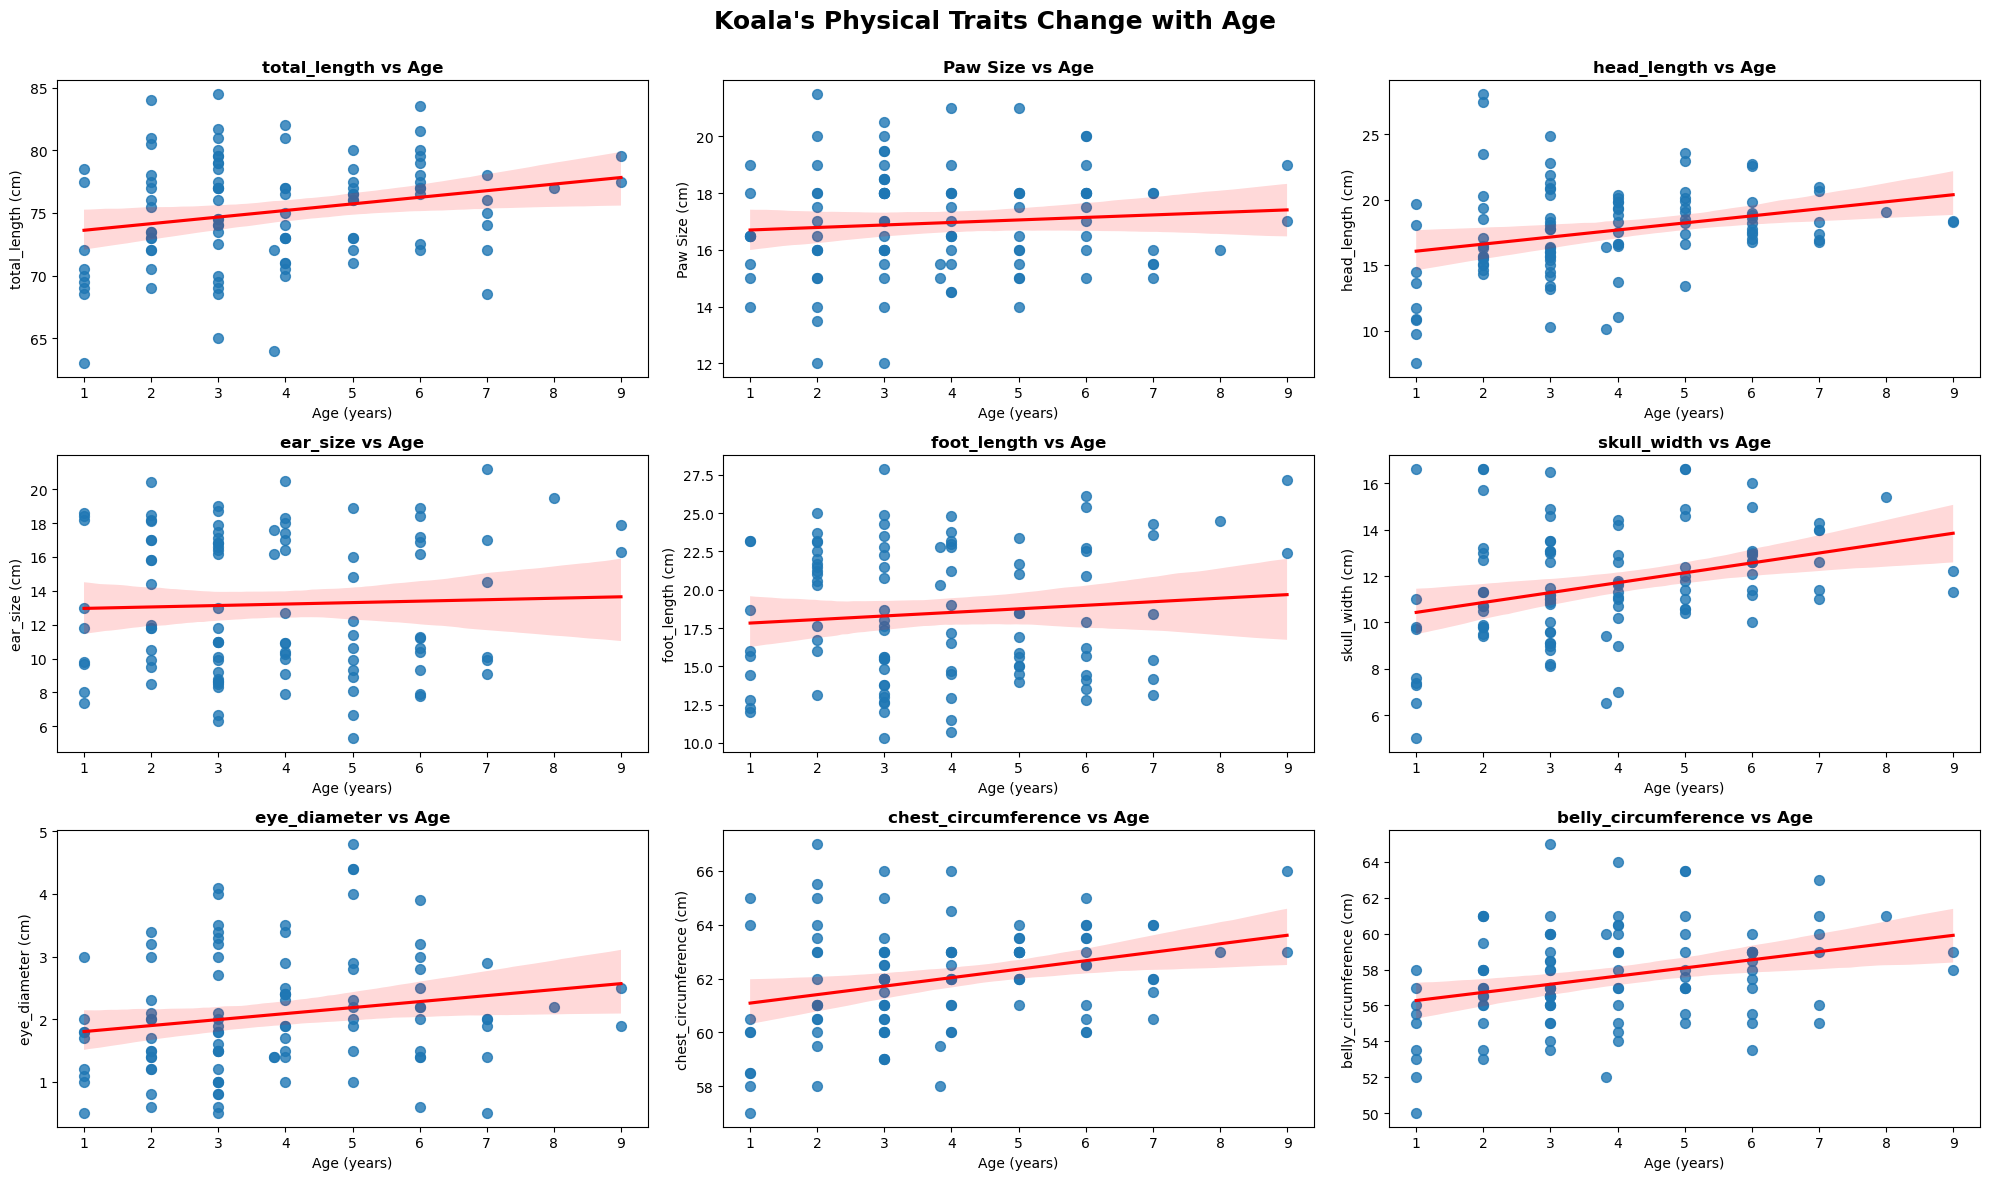

In [43]:
# Creating the figure for subplots
plt.figure(figsize=(20, 12))

# Looping over characteristic columns to create individual subplots
for idx, col in enumerate(characteristic_cols, 1):
    plt.subplot(3, 3, idx)
    sns.regplot(x='age_in_years', y=col, data=koala, scatter_kws={"s": 50}, line_kws={"color": "red"})
    plt.title(f'{col} vs Age', weight='bold')
    plt.xlabel('Age (years)')
    plt.ylabel(f'{col} (cm)')

# Adjust the layout to fit the overarching title correctly
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Adding an overarching title
plt.suptitle("Koala's Physical Traits Change with Age", fontsize=18, weight='bold')

plt.show()

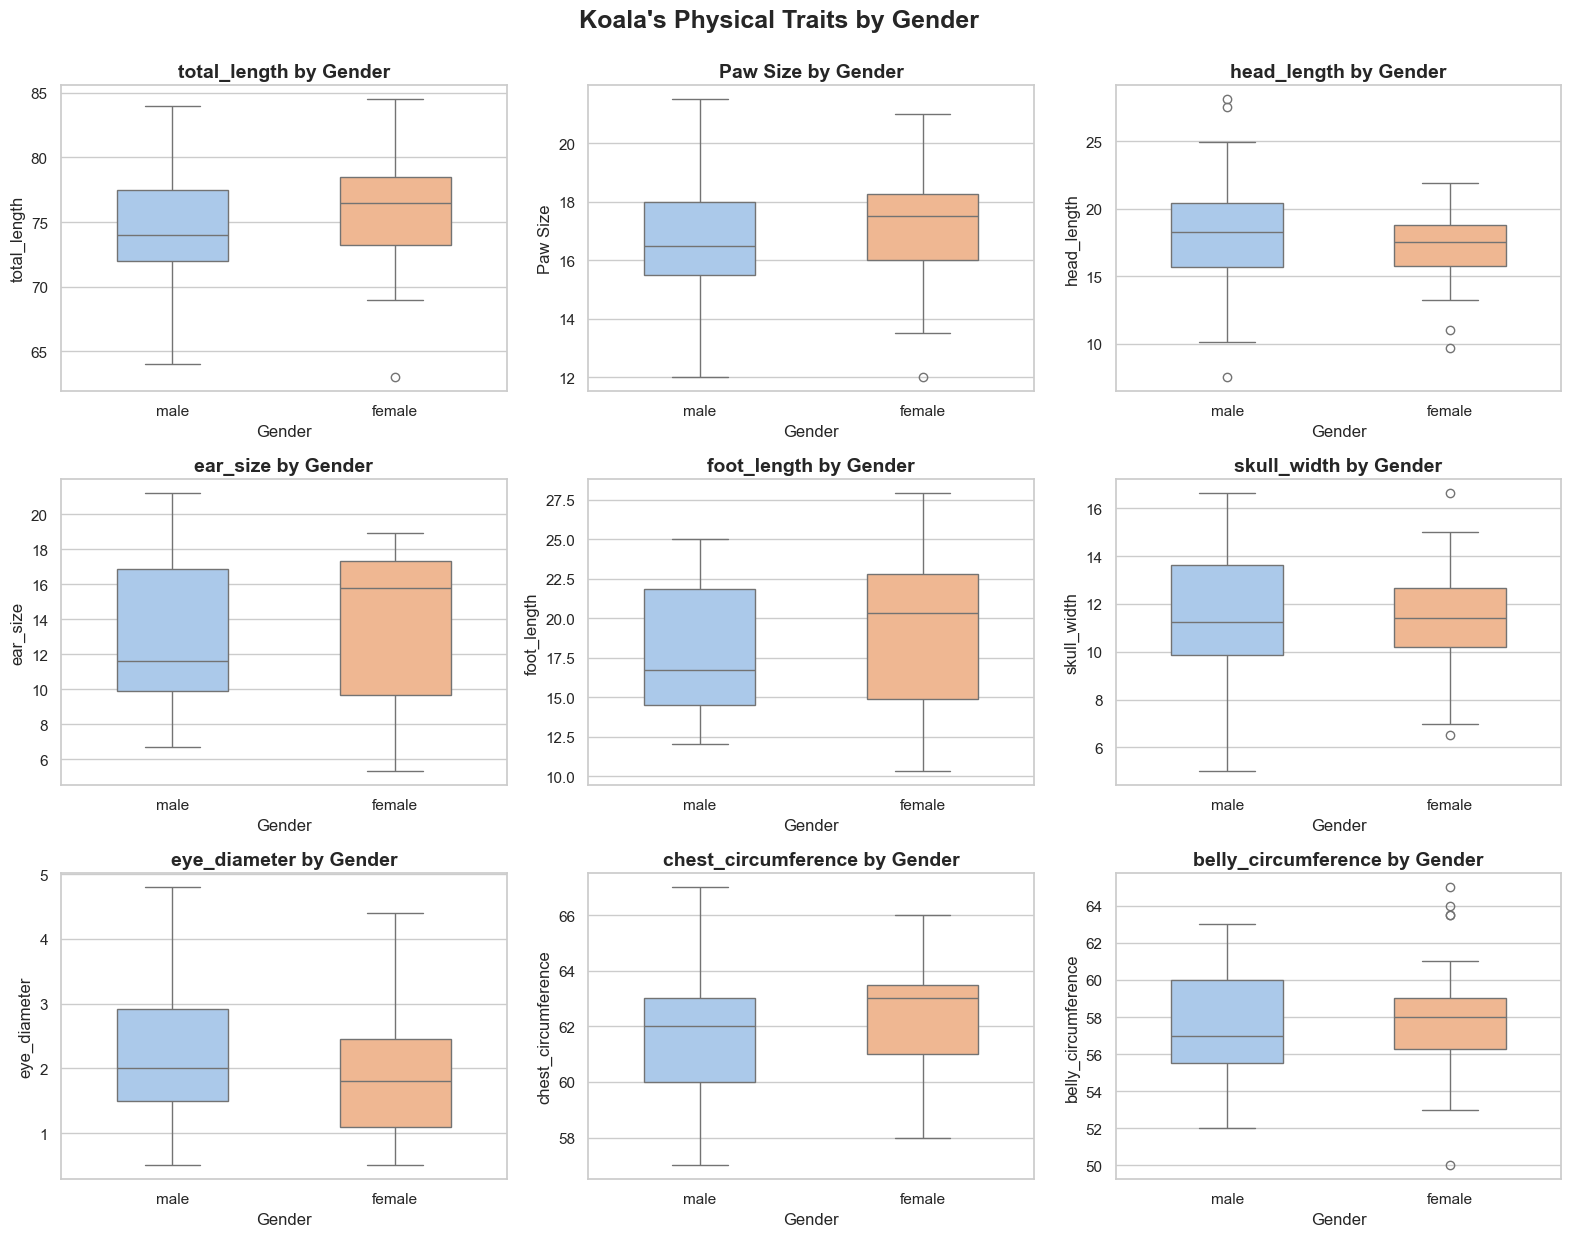

In [44]:
# Set a theme for the plot
sns.set_theme(style="whitegrid")

# Create a figure with 5 rows and 2 columns of subplots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Define custom colors for the boxplots
custom_palette = sns.color_palette("pastel")

# Loop through the characteristic columns and plot boxplots in subplots
for i, col in enumerate(characteristic_cols):
    sns.boxplot(x='gender', y=col, data=koala, ax=axes[i], palette=custom_palette,width=0.5)
    
    # Set titles, labels, and custom font sizes for better readability
    axes[i].set_title(f'{col} by Gender', fontsize=14, weight='bold')
    axes[i].set_xlabel('Gender', fontsize=12)
    axes[i].set_ylabel(col, fontsize=12)

# Adjust layout to prevent overlap between subplots
plt.tight_layout()

# Add a main title to the figure
fig.suptitle("Koala's Physical Traits by Gender", fontsize=18, weight='bold', y=1.03)

plt.savefig("Koala's Physical Traits by Gender.jpg")
# Show the final plot
plt.show()

## Section 3: Analysis

Please provide answers to the following questions:

3.1) Is the mean head length of the Koalas significantly different from 92.0 mm? \
3.2) Do male and female Koalas have significantly different mean head lengths? \
3.3) Can we predict the total length of a Koala based on its head length? \
3.4) Can we predict the total length of a Koala based on multiple factors such as head 
length, skull width and  foot lenth. \
3.5)  Do environmental factors such as state affect Koala’s physical characteris \
3.6)  What factors are correlated with the total length of aKoalaa 

### 3.1) Significant Difference in Mean Head Length Compared to 92.0 mm?

**State the hypothesis:**
- <u>Null hypothesis (H₀)</u>:  The mean head length of koalas is equal to 92.0 mm.
- <u>Alternative hypothesis (H₁)</u>: The mean head length of koalas is not equal to 92.0 mm (two-tailed test).

**Perform the One-Sample t-Test**

In [50]:
t_stat, p_value = stats.ttest_1samp(koala['head_length'], 92.0)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

T-statistic: -206.8002093977195
P-value: 3.1847817062976576e-131


Typically, a significance level (alpha) of 0.05 is used, which means that there is a 5% risk of concluding that a difference exists when there is no actual difference.

**Interpret the result**

In [53]:
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: The mean head length is significantly different from 92.0 mm.")
else:
    print("Fail to reject the null hypothesis: The mean head length is not significantly different from 92.0 mm.")

Reject the null hypothesis: The mean head length is significantly different from 92.0 mm.


Based on the t-statistic and the p-value, determine whether the mean head length of koalas differs significantly from the hypothesized value. It is clear that p-value is less than the chosen alpha level (0.05), so, reject the null hypothesis, indicating that the mean of head legth is significantly different from 92.0 mm.

### 3.2) Significant Difference in Mean Head Length between male and female koalas?

**State the hypothesis:**
- <u>Null hypothesis (H₀)</u>: The mean head length of male koalas is equal to the mean head length of female koalas.
- <u>Alternative hypothesis (H₁)</u>: The mean head length of male koalas is not equal to the mean head length of female koalas (two-tailed test).

**Collect and Prepare Data** \
Extract the head lengths for male and female koalas from your dataset. Ensure your data is correctly segmented by gender.

In [58]:
m_head_lengths = koala[koala['gender'] == 'male']['head_length']
f_head_lengths = koala[koala['gender'] == 'female']['head_length']
print(m_head_lengths.mean())
print(f_head_lengths.mean())

17.944642857142856
17.148837209302325


**Perform the Two-Sample t-Test** \
compares the means of two independent samples.

In [60]:
t_stat, p_value = stats.ttest_ind(m_head_lengths, f_head_lengths)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

T-statistic: 1.0975520598985093
P-value: 0.27511723267891625


**Interpret the result**

In [62]:
alphalpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: Male and female koalas have significantly different head lengths.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in head length between male and female koalas.")

Fail to reject the null hypothesis: There is no significant difference in head length between male and female koalas.


Based on the p-value, conclude whether there is a significant difference in the mean head lengths of male and female koalas. Since p-value is not below the alpha value, so it is fail to reject the null hypothesis where can be concluded that there is no significant difference in head length between male and female koalas.

### 3.3) Prediction of ‘Total Length’ of a Koala based on its ‘Head Length’

In [65]:
ols_data = koala[["total_length", "head_length"]]

# Write out formula  = Y~X
ols_formula = "total_length ~ head_length"

### Perform OLS Regression Model

In [67]:
from statsmodels.formula.api import ols
OLS = ols(formula = ols_formula, data = ols_data)
model = OLS.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           total_length   R-squared:                       0.463
Model:                            OLS   Adj. R-squared:                  0.458
Method:                 Least Squares   F-statistic:                     83.76
Date:                Mon, 14 Oct 2024   Prob (F-statistic):           9.09e-15
Time:                        20:15:35   Log-Likelihood:                -254.19
No. Observations:                  99   AIC:                             512.4
Df Residuals:                      97   BIC:                             517.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      60.6211      1.614     37.549      0.000      57.417      63.825
head_length     0.8229      0.090      9.152      0.000       0.644       1.001
==============================================================================
Omnibus:                        0.496   Durbin-Watson:                   1.640
Prob(Omnibus):                  0.781   Jarque-Bera (JB):                0.640
Skew:                          -0.070   Prob(JB):                        0.726
Kurtosis:                       2.632   Cond. No.                         90.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Intepret the model summary

- The model's R-squared value of 0.463 indicates that approximately 46.3% of the variability in total length can be explained by head length. The coefficient for head length is 0.8229, suggesting that for every one-millimeter increase in head length, the total length increases by approximately 0.8229 millimeters.
- The significant p-value for the head length coefficient (less than 0.05) confirms that head length is a statistically significant predictor of total length in koalas. This suggests a practical application in studying koala morphology.
- However, there is potential limitations of model, since the R-squared only indicate 46.3% of the variability, while over 50% of the remains unexplained, suggesting other factors may also influence total length. Future studies could explore additional variables such as age, gender, or other characteristics.


### Assumption checks

**Check the assumptions of linear regression model**

- Linearity: Each predictor variable (Xi) is linearly related to the outcome variable (Y).
- Normality: The errors are normally distribute.*
- Independent Observations: Each observation in the dataset is independent.
- Homoscedasticity: The variance of the errors is constant or similar across model.*

**Normality Check**

Normality Check: A histogram of the residuals with a kernel density estimate (KDE) overlay provides a visual assessment of normality. Ideally, the residuals should form an approximately normal distribution centered around zero, indicated by a bell-shaped curve in the KDE.

In [74]:
#lets check the Normality: The errors are normally distribute.*

# Extract residuals and fitted values
residuals = model.resid
fitted_values = model.fittedvalues

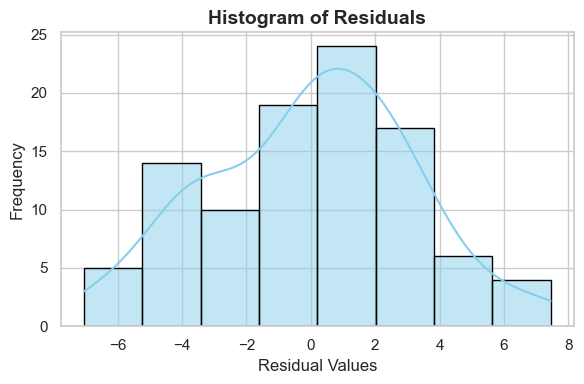

In [75]:
# Create a 1x2 grid of subplots
plt.figure(figsize=(6, 4))  # Adjust the figure size

# Create a histogram with KDE for the residuals
sns.histplot(residuals, kde=True, color='skyblue', edgecolor='black')

# Set title and labels with custom font sizes
plt.title('Histogram of Residuals', fontsize=14, weight='bold')
plt.xlabel('Residual Values', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Tighten the layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

**Check Linearity and Homoscedasticity:**

Linearity and Homoscedasticity Check: "The scatter plot of residuals versus fitted values should show no clear pattern or systematic structure. The presence of a random scatter supports the assumptions of linearity and homoscedasticity. A horizontal line at zero indicates no bias in the residuals.

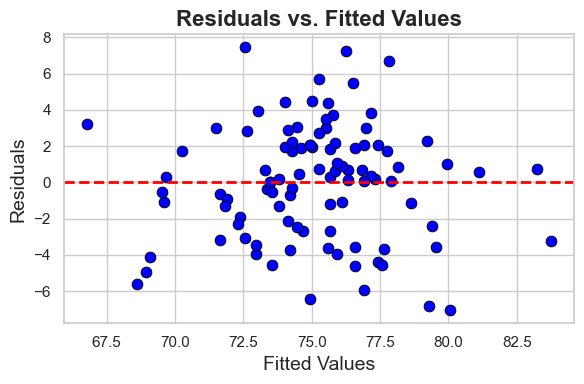

In [78]:
# Residuals vs. Fitted values plot = To check for homoscedasticity,

# Scatter plot of residuals vs. fitted values
plt.figure(figsize=(6, 4))

# Create the scatter plot with distinct color and marker style
sns.scatterplot(x=fitted_values, y=residuals, color='blue', s=60, edgecolor='black')

# Add a horizontal line at y=0 to indicate zero residual
plt.axhline(0, color='red', linestyle='--', linewidth=2)

# Set title and labels with larger font size for better readability
plt.title('Residuals vs. Fitted Values', fontsize=16, weight='bold')
plt.xlabel('Fitted Values', fontsize=14)
plt.ylabel('Residuals', fontsize=14)

# Improve spacing around plot
plt.tight_layout()

# Show the plot
plt.show()

In conclusion, it is capable to predict the total length of a koala based on its head length. The linear regression analysis shows that head length is a statistically significant predictor of total length. The model indicates that for every one millimeter increase in head length, the total length of a koala increases by approximately 0.8229 millimeters.

However, it's important to note that while the model is statistically significant, it explains about 46.3% of the variability in total length based on head length alone. This suggests that other factors also influence the total length of a koala, and including additional variables could potentially improve the predictability of the model.

### 3.4) Prediction of ‘Total Length’ of a Koala based on its ‘Head Length’, ‘Skull Width’ and ‘Foot Length’

In [81]:
# Define the dependent variable (y) and independent variables (X)
X = koala[['head_length', 'skull_width', 'foot_length']]  # Predictors
y = koala['total_length'] # Predicted

### Perform Multiple Linear Regression

In [83]:
import statsmodels.api as sm

# Add constant to X for the intercept
X = sm.add_constant(koala[['head_length', 'skull_width', 'foot_length']])

# Fit the multiple regression model
model = sm.OLS(y, X).fit()

# Display the summary of the regression model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           total_length   R-squared:                       0.511
Model:                            OLS   Adj. R-squared:                  0.496
Method:                 Least Squares   F-statistic:                     33.15
Date:                Mon, 14 Oct 2024   Prob (F-statistic):           9.46e-15
Time:                        20:15:37   Log-Likelihood:                -249.54
No. Observations:                  99   AIC:                             507.1
Df Residuals:                      95   BIC:                             517.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          57.9552      1.784     32.478      

- R-squared value of 0.511: This indicates that approximately 51.1% of the variability in total length can be explained by the head length, skull width, and foot length.
- Head Length coefficient (0.5864): For every 1 mm increase in head length, the total length increases by approximately 0.5864 mm.
- Foot Length coefficient (0.2063): For every 1 mm increase in foot length, the total length increases by approximately 0.2063 mm.
- Skull Width: Although the coefficient is positive, the p-value (0.200) suggests that it is not statistically significant in this model.

### Assumption checks

**Check the assumptions of linear regression model**

- Linearity: Each predictor variable (Xi) is linearly related to the outcome variable (Y).
- Normality: The errors are normally distribute.*
- Independent Observations: Each observation in the dataset is independent.
- Homoscedasticity: The variance of the errors is constant or similar across model.*

**Check Normality**

Histogram and QQ-Plot: Use these plots to assess whether the residuals follow a normal distribution, which is crucial for the validity of the statistical tests employed in regression analysis.

In [89]:
# Get the residuals
residuals = model.resid

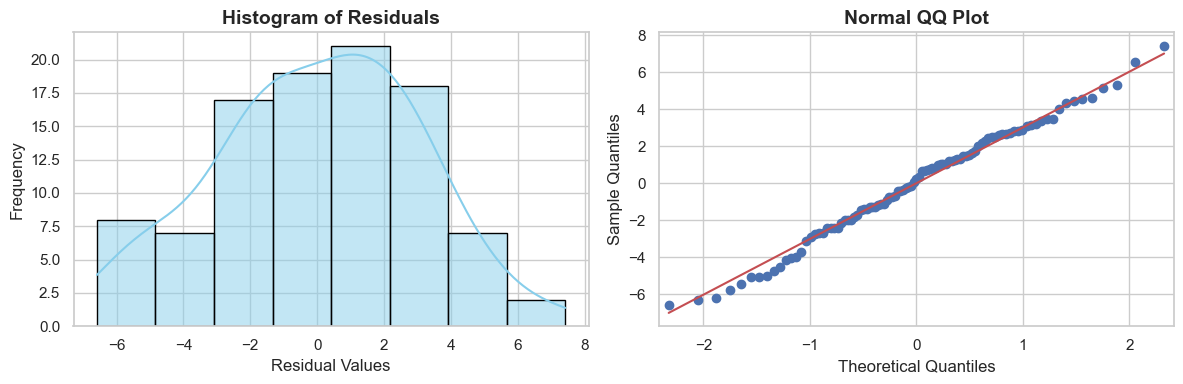

In [90]:
# Create a 1x2 grid of subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Set a style for the plots
sns.set_theme(style="whitegrid")

# Create a histogram with KDE for the residuals
sns.histplot(residuals, kde=True, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_xlabel('Residual Values', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Histogram of Residuals', fontsize=14, weight='bold')

# Create a QQ plot of the residuals
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title('Normal QQ Plot', fontsize=14, weight='bold')

# Tighten the layout to prevent overlapping elements
plt.tight_layout()

# Show the plots
plt.show()

Suggest residuals approximate normal distribution, though slight deviations exist.

### Homoscedasticity Check

Residuals vs. Fitted Values Plot: Explain what this plot shows regarding the assumption of equal variance and linearity in relationships.

In [94]:
# Get fitted values
fitted_vals = model.fittedvalues

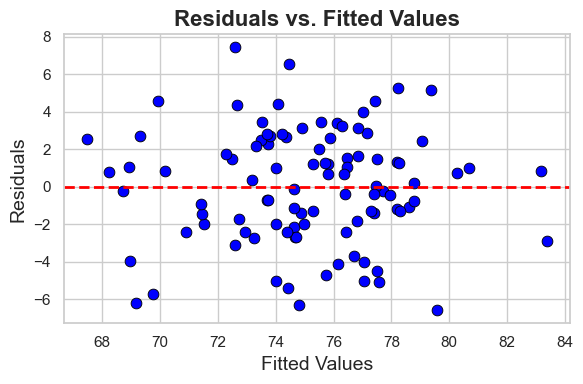

In [95]:
# Scatter plot of residuals vs. fitted values
plt.figure(figsize=(6, 4))

# Create the scatter plot with distinct color and marker style
sns.scatterplot(x=fitted_vals, y=residuals, color='blue', s=60, edgecolor='black')

# Add a horizontal line at y=0 to indicate zero residual
plt.axhline(0, color='red', linestyle='--', linewidth=2)

# Set title and labels with larger font size for better readability
plt.title('Residuals vs. Fitted Values', fontsize=16, weight='bold')
plt.xlabel('Fitted Values', fontsize=14)
plt.ylabel('Residuals', fontsize=14)

# Improve spacing around plot
plt.tight_layout()

# Show the plot
plt.show()

Indicating homoscedascity

### Multicollinearity Check

To ensure that the regression model is not adversely affected by multicollinearity, I calculated the Variance Inflation Factor (VIF) for each predictor variable. VIF quantifies the extent of correlation between one predictor and the rest of the predictors in a model. It provides an index that measures how much the variance of an estimated regression coefficient increases if your predictors are correlated.

In [99]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns

vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Display the VIF data
print(vif_data)

       Feature        VIF
0        const  33.403639
1  head_length   2.712194
2  skull_width   2.581853
3  foot_length   1.165581


The rule of thumb is that if VIF is:

1: Not correlated. \
1 - 5: Moderately correlated. \
Above 5: Highly correlated, indicating potential problems due to multicollinearity.

VIF Results:
Constant: The VIF for the constant term is usually ignored in interpretation as it does not provide information about predictor variables.\
Head Length: VIF = 2.71294, suggests a moderate level of multicollinearity, which may not be problematic.\
Skull Width: VIF = 2.58183, also indicates a moderate level of multicollinearity.\
Foot Length: VIF = 1.165581, shows very little multicollinearity with other variables.

While the VIF scores indicate a moderate correlation between head length and skull width, the scores are within acceptable limits, suggesting that our model’s coefficients are reliable for inference. The absence of strong multicollinearity supports the robustness of our findings that head length and foot length significantly predict the total length of a koala.

### Linearlity Check

Ensure that the relationship between independent variables and the dependent variable is linear.

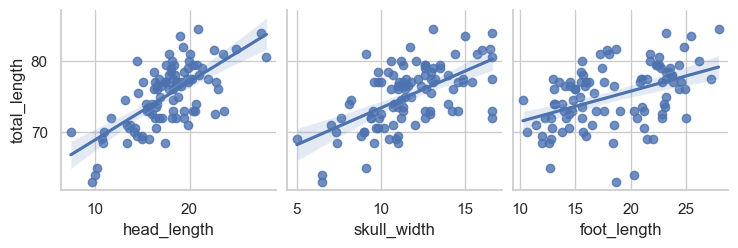

In [104]:
# Pairplot to visualize relationships
sns.set_theme(style="whitegrid")
sns.pairplot(koala, x_vars=['head_length', 'skull_width', 'foot_length'], y_vars='total_length', kind='reg', height=2.5)

plt.show()

- head_length vs total_length: There seems to be a positive linear relationship, indicated by the upward slope of the regression line. As head length increases, total length tends to increase.
- skull_width vs total_length: The relationship appears slightly weaker, but there's still a positive trend visible. The points are a bit more scattered around the regression line.
- foot_length vs total_length: Similar to the other two variables, there is a slight positive trend, though the data points are more dispersed compared to head length.

In conclusion, this multiple linear regression model indicates that head length and foot length are significant predictors of total length in koalas, while skull width does not appear to have a statistically significant impact. The model explains 51.1% of the variation in total length, suggesting that while head length and foot length are important factors, there are likely other variables influencing total length that have not been included in the mode. Including more predictors could provide a comprehensive analysis.

### 3.5) Examining the Impact of Habitat (State) on Koala Physical Characteristics

In order to finding whether the habitat or state is affect to Koala's physical characteristic, it is needed to encoding this categorical value into numeric in order to proper identify the correlation acted on others numeric feature

In [109]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['gender', 'habitat']

# Perform one-hot encoding on the 'habitat' column, dropping the first category
koala_encoded = pd.get_dummies(koala, columns=categorical_cols, drop_first=True)

# Convert any boolean columns to integers (in case there are any)
koala_encoded = koala_encoded.astype(int)

# Display the first few rows of the encoded DataFrame
koala_encoded.head()

,koala_id,region,age_in_years,Paw Size,total_length,head_length,ear_size,foot_length,skull_width,eye_diameter,chest_circumference,belly_circumference,gender_male,habitat_VIC
0,1,1,8,16,77,19,19,24,15,2,63,61,1,1
1,2,1,6,16,79,17,16,22,12,3,63,58,0,1
2,3,1,6,19,83,19,16,25,15,2,65,59,0,1
3,4,1,6,18,80,18,17,26,12,2,63,59,0,1
4,5,1,2,16,73,16,18,21,11,2,63,58,0,1


In [110]:
# Identify the characteristic column
characteristic_cols = ['Paw Size', 'total_length', 'head_length', 'ear_size',
                       'foot_length', 'skull_width', 'eye_diameter', 
                       'chest_circumference', 'belly_circumference']

habitat_col = koala_encoded.filter(like='habitat').columns.tolist()
charWithHabitat = koala_encoded[characteristic_cols + list(habitat_col)]

#crate correlation matrix between habitat and characteristic col
correlation_matrix = charWithHabitat.corr()

In [111]:
correlation_matrix['habitat_VIC'].drop('habitat_VIC').sort_values(ascending = False).reset_index()

,index,habitat_VIC
0,ear_size,0.878375
1,foot_length,0.805319
2,chest_circumference,0.230076
3,total_length,0.085825
4,belly_circumference,0.032651
5,head_length,0.003633
6,skull_width,-0.057307
7,eye_diameter,-0.217716
8,Paw Size,-0.477885


- **Ear Size (0.878375) and Foot Length (0.805319):** \
The strong positive correlations with ear size and foot length suggest that koalas in VIC tend to have larger ear sizes and longer foot lengths compared to those in QLD. This could imply that environmental factors specific to VIC (e.g., climate, terrain, food sources) lead to these traits being more prominent in VIC koalas.

- **Paw Size (-0.477885):** \
The moderately negative correlation indicates that koalas in VIC tend to have smaller paw sizes than those in QLD. The environmental factors in QLD might favor larger paw sizes or, conversely, VIC's environment might contribute to smaller paw sizes.

- **Total Length (0.085825) and Chest Circumference (0.238076):** \
These characteristics show small positive correlations with VIC, meaning that koalas in VIC may have slightly longer total body length and larger chest circumference compared to QLD koalas. However, these relationships are much weaker, implying that the differences are not as pronounced as those for ear size and foot length.
- **Skull Width (-0.057307) and Eye Diameter (-0.217716):** \
These traits exhibit weak negative correlations, implying minimal differences between koalas in VIC and QLD in terms of skull width and eye diameter.

Remaining weak and moderately negative correlations suggest that these traits don’t vary significantly between VIC and QLD, or if they do, VIC koalas might have slightly narrower skulls and smaller eye diameters compared to QLD koalas.

Create a boxplot to illustrate furtherthe distribution of various koala physical characteristics, differentiated by habitat or state.

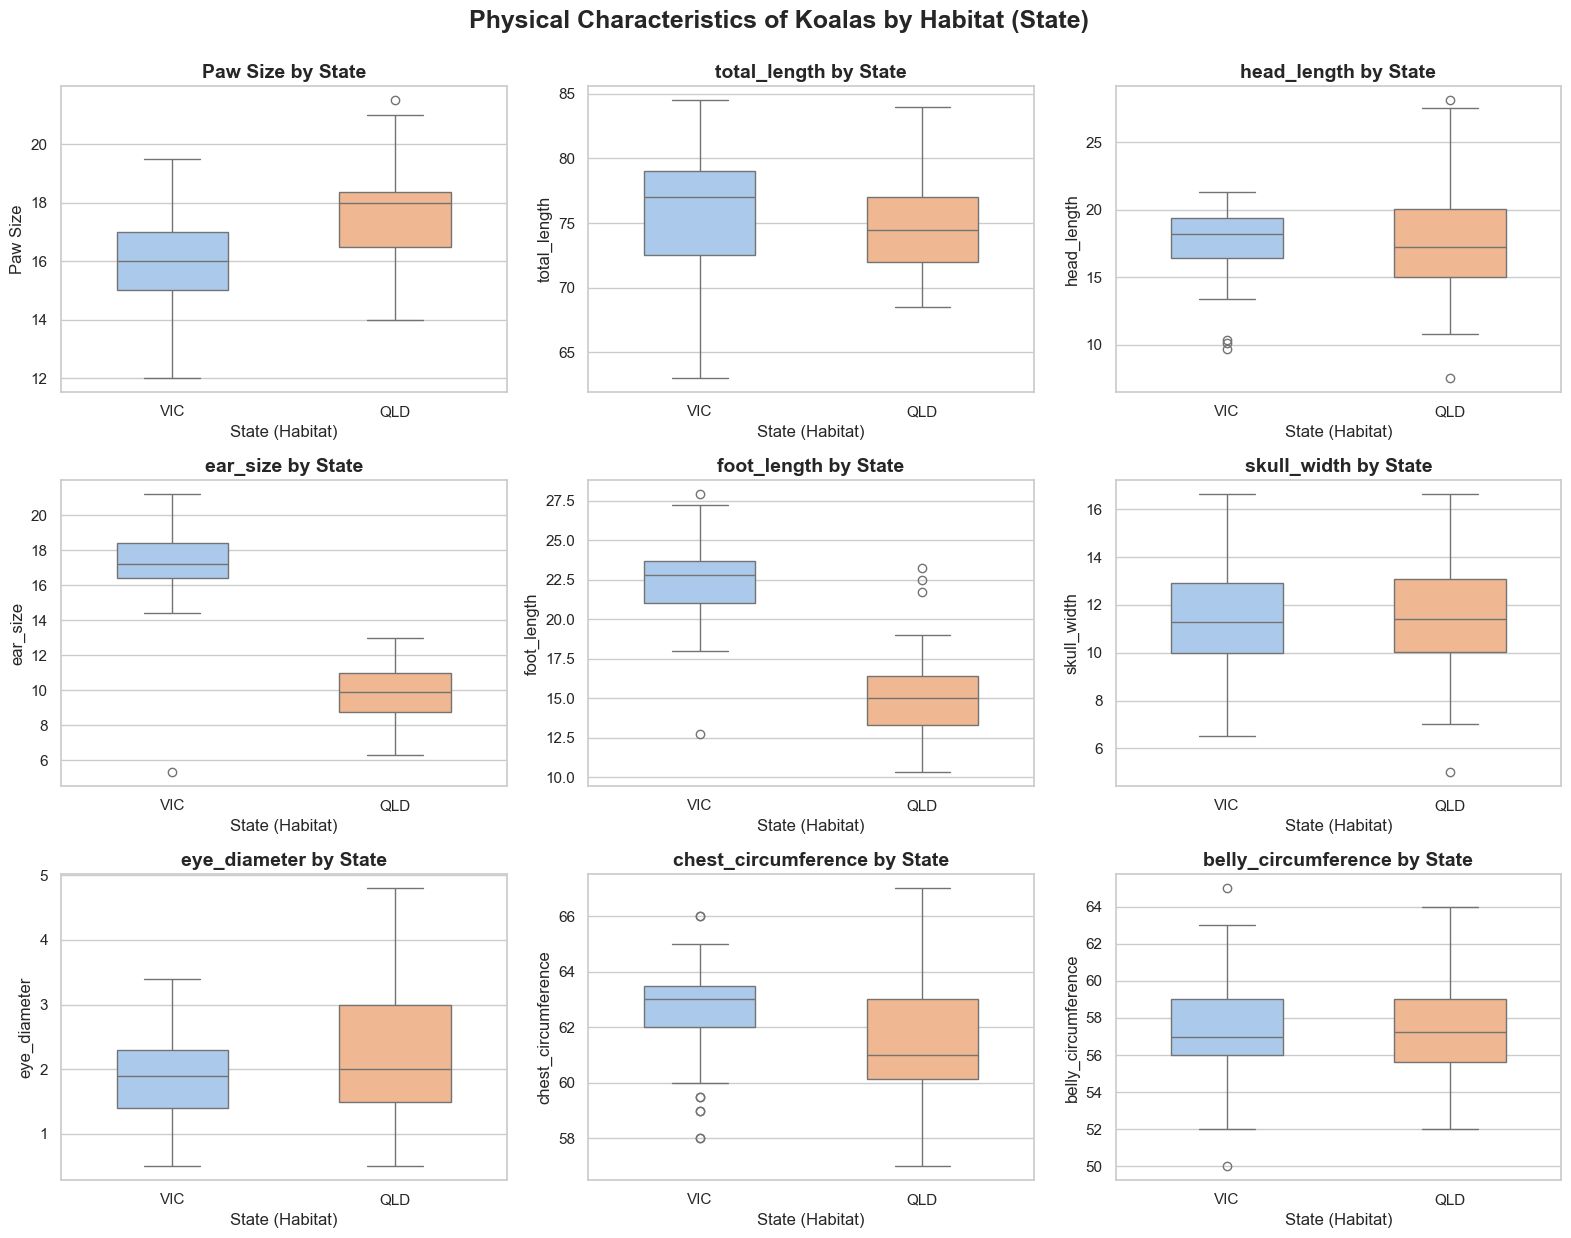

In [114]:
# Set a theme for the plot
sns.set_theme(style="whitegrid")

# Create a figure with 5 rows and 2 columns of subplots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Define custom colors for the boxplots
custom_palette = sns.color_palette("pastel")

# Loop through the characteristic columns and plot boxplots in subplots
for i, col in enumerate(characteristic_cols):
    sns.boxplot(x='habitat', y=col, data=koala, ax=axes[i], palette=custom_palette,width=0.5)
    
    # Set titles, labels, and custom font sizes for better readability
    axes[i].set_title(f'{col} by State', fontsize=14, weight='bold')
    axes[i].set_xlabel('State (Habitat)', fontsize=12)
    axes[i].set_ylabel(col, fontsize=12)

# Adjust layout to prevent overlap between subplots
plt.tight_layout()

# Add a main title to the figure
fig.suptitle('Physical Characteristics of Koalas by Habitat (State)', fontsize=18, weight='bold', y=1.03)


# Show the final plot
plt.show()

- Total Length: Koalas in Queensland (QLD) tend to have a longer total body length compared to those in Victoria (VIC). 
- Paw Size: There's a slight variation in paw size, with QLD koalas showing slightly larger paws.
- Head Length: QLD koalas also appear to have longer heads on average than those in VIC.
- Ear Size: Ear sizes of koalas are notably smaller in QLD compared to VIC.
- Foot Length: Foot length is quite similar between the states, though QLD shows a slightly higher average.
- Skull Width: QLD koalas have wider skulls compared to those in VIC.
- Eye Diameter: VIC koalas have larger eye diameters than those in QLD.
- Chest Circumference: Chest circumference is greater in QLD koalas.
- Belly Circumference: Belly circumference is relatively similar between the states, with a slight tendency for larger sizes in QLD.

### 3.6) Correlated Factors with the total length of Koala

In [117]:
# Create the correlation matrix while drop the koala_id which is identifier
correlation_matrix = koala_encoded.drop(columns = 'koala_id').corr()

# Drop self-correlation to avoid redundancy
total_length_corr = correlation_matrix['total_length'].drop('total_length') 

# Sort the correlation value
total_length_corr_sorted = total_length_corr.sort_values(ascending = False)

total_length_corr_sorted.reset_index()

,index,total_length
0,head_length,0.678261
1,skull_width,0.597073
2,Paw Size,0.570930
3,chest_circumference,0.547890
4,belly_circumference,0.517153
5,foot_length,0.436471
6,age_in_years,0.247148
7,eye_diameter,0.205122
8,ear_size,0.154247
9,habitat_VIC,0.085825


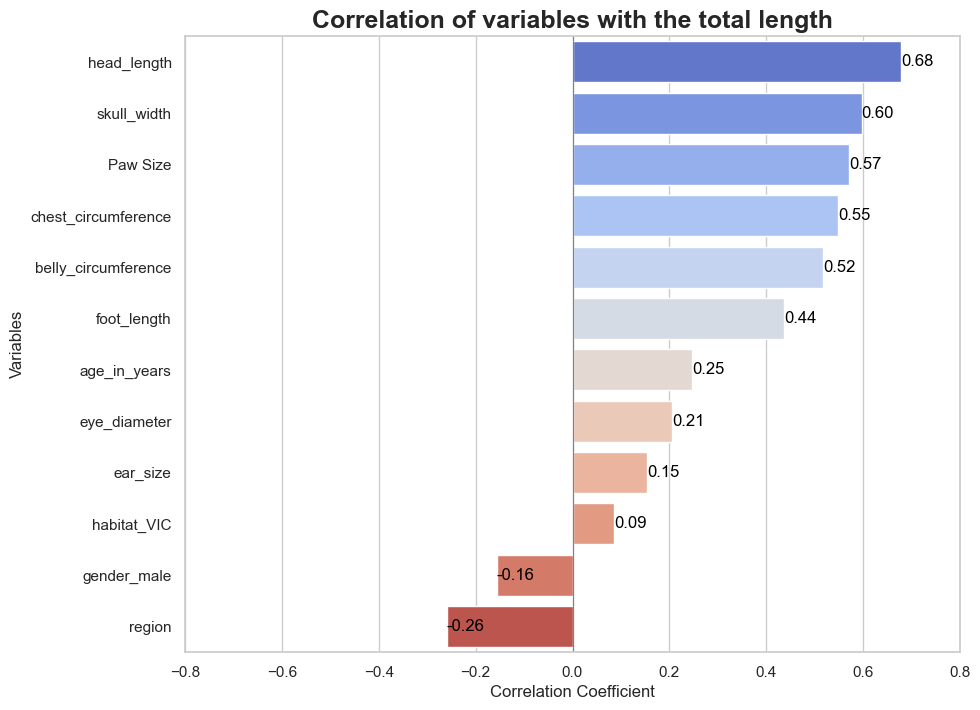

In [118]:
# Create a sorted bar chart

# Assuming total_length_corr_sorted is your pre-sorted Series of correlation coefficients
plt.figure(figsize=(10, 8))
barplot = sns.barplot(x=total_length_corr_sorted.values, y=total_length_corr_sorted.index, palette="coolwarm")
plt.xlabel('Correlation Coefficient')
plt.ylabel('Variables')
plt.title('Correlation of variables with the total length', fontsize=18, weight='bold')
plt.xlim(-0.8,0.8)
plt.axvline(0, color='grey', linewidth=0.8)  # Adds a vertical line at zero for reference

# Annotate each bar with the value of the correlation coefficient
for index, value in enumerate(total_length_corr_sorted):
    plt.text(value, index, f'{value:.2f}', color='black', va='center')

plt.show()


- Head length (0.68): The strongest positive correlation with total length. This suggests that as the head length increases, the total length of the koala also tends to increase.
- Skull Width (0.60): Another strong positive correlation, indicating that koalas with wider skulls also tend to have longer bodies.
- Paw Size (0.57): Koalas with larger paw sizes tend to have longer total body lengths.
- Chest (0.55)/ Belly Circumference (0.52): These also show strong positive correlations with total length, suggesting that koalas with larger circumferences tend to be longer in body size.
- Foot Length (0.44): A moderate positive correlation, indicating that longer foot lengths are somewhat associated with longer body lengths.


### Session 4: Recommendation
This session has been documented in a report file